In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.metrics import mean_squared_error

In [5]:
#Reading the data from a csv file and checking the output

dataset = pd.read_csv("qm9.csv")

dataset.describe()

,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
count,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000
mean,9.814382,1.406097,1.124921,2.706037,75.191296,-0.239977,0.011124,0.251100,1189.527450,0.148524,-411.543985,-411.535513,-411.534569,-411.577397,31.600676,-1750.812997,-1761.480647,-1771.546928,-1629.388196
std,1809.465666,1.583795,1.095618,1.530394,8.187793,0.022131,0.046936,0.047519,279.757172,0.033274,40.060230,40.060012,40.060012,40.060741,4.062471,239.313373,241.436103,243.151065,220.207088
min,0.000000,0.337120,0.331180,0.000000,6.310000,-0.428600,-0.175000,0.024600,19.000200,0.015951,-714.568061,-714.560153,-714.559209,-714.602138,6.002000,-2608.448864,-2626.408172,-2643.007040,-2417.121997
25%,2.554430,1.091630,0.910480,1.588700,70.380000,-0.252500,-0.023800,0.216300,1018.322600,0.125289,-437.913936,-437.905942,-437.904997,-437.947682,28.942000,-1904.772194,-1916.981009,-1928.181417,-1771.350603
50%,3.090360,1.369940,1.078560,2.500000,75.500000,-0.241000,0.012000,0.249400,1147.585800,0.148329,-417.864758,-417.857351,-417.856407,-417.895731,31.555000,-1753.464714,-1764.090324,-1774.151176,-1632.224955
75%,3.835820,1.653980,1.279540,3.636100,80.520000,-0.228700,0.049200,0.288200,1308.816600,0.171150,-387.049166,-387.039746,-387.038802,-387.083279,34.276000,-1596.871098,-1606.108658,-1615.066349,-1488.291333
max,619867.683140,437.903860,282.945450,29.556400,196.620000,-0.101700,0.193500,0.622100,3374.753200,0.273944,-40.478930,-40.476062,-40.475117,-40.498597,46.969000,-213.087624,-213.974294,-215.159658,-201.407171


# QM9 Dataset Feature Guide

This dataset is based on the QM9 molecular dataset, which contains small organic molecules with quantum-chemistry–computed properties.

Each row corresponds to one molecule.

---

## Identifiers

### mol_id
- Unique identifier for each molecule
- Not useful for ML models
- Safe to drop during preprocessing

---

### smiles
- SMILES string representation of the molecule
- Encodes:
  - atoms
  - bonds
  - molecular connectivity

Example:
CCO → ethanol

Used for:
- converting molecules into graphs
- generating fingerprints (e.g., RDKit)

---

## Geometry-related features

### A, B, C
- Rotational constants (GHz)
- Describe how the molecule rotates in 3D
- Related to molecular shape and moment of inertia

Intuition:
- elongated molecules vs compact molecules rotate differently

---

### r2
- Electronic spatial extent
- Measures how spread out the electron cloud is
- Rough proxy for molecular size

---

## Electronic properties

### mu
- Dipole moment (Debye)
- Measures charge separation in the molecule

Intuition:
- how polar the molecule is

---

### alpha
- Polarizability
- Measures how easily the electron cloud is distorted

Intuition:
- rigid vs “squishy” electron cloud

---

### homo
- Highest Occupied Molecular Orbital energy
- Energy of the most energetic occupied electron

Intuition:
- how easily the molecule donates electrons

---

### lumo
- Lowest Unoccupied Molecular Orbital energy
- First available empty electron state

Intuition:
- how easily the molecule accepts electrons

---

### gap
- HOMO–LUMO energy gap

Formula:
E_gap = E_LUMO - E_HOMO

Interpretation:
- small gap → reactive, conductive
- large gap → stable, insulating

---

## Vibrational / quantum properties

### zpve
- Zero-point vibrational energy
- Energy from quantum vibrations even at 0 K

Intuition:
- atoms always vibrate, even at absolute zero

---

### cv
- Heat capacity at constant volume
- Energy required to raise temperature

---

## Thermodynamic energies

### u0
- Internal energy at 0 K

### u298
- Internal energy at 298 K (room temperature)

### h298
- Enthalpy at 298 K

### g298
- Gibbs free energy at 298 K

Formula:
G = H - T*S

Interpretation:
- predicts thermodynamic favorability

---

## Atom-normalized energies

### u0_atom
### u298_atom
### h298_atom
### g298_atom

- Same as above but normalized per atom
- Related to atomization energy
- Measures bond stability

In [ ]:
#Preparing the data for gap prediction

X = dataset[[
    "A", 
    "B", 
    "C", 
    "mu", 
    "zpve", 
    "cv"
]]

y = dataset["gap"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=144
)

In [9]:
#Training the Boosted tree

gboost = GradientBoostingRegressor(
    learning_rate=0.05,
    n_estimators=100,
    max_depth=3
)

gboost.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

MSE (tesing):  0.0012133198085021676
MSE (training):  0.001187996646289174


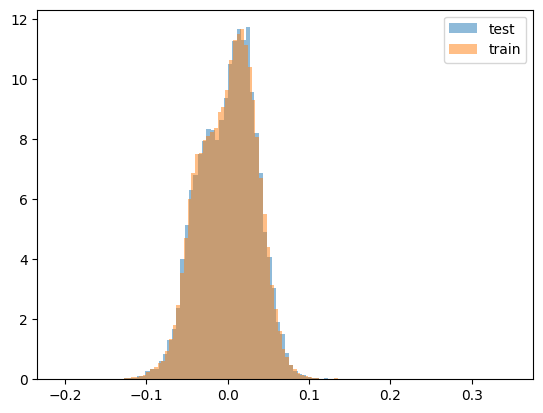

In [21]:
#Testing the tree for MSE and overfitting comparision

y_test_predicted = gboost.predict(X_test)

mse = mean_squared_error(y_test, y_test_predicted)
print("MSE (tesing): ", mse)

y_train_predicted = gboost.predict(X_train)

mse_training = mean_squared_error(y_train, y_train_predicted)
print("MSE (training): ", mse_training)

r_test = y_test - y_test_predicted
r_train = y_train - y_train_predicted

plt.hist(r_test, bins=100, alpha=0.5, density=True, label="test")
plt.hist(r_train, bins=100, alpha=0.5, density=True, label="train")
plt.legend()
plt.show()

In [ ]:
cvs = cross_val_score(gboost, X, y, cv=5, scoring="neg_mean_squared_error")

print(-cvs.mean())

0.0012886039701507617
